# Práctica clase 2
Transformer completo Encoder-Decoder para traducción simple Inglés-Francés

Incluye:
1. Dataset pequeño preparado
2. Vocabularios y DataLoader
3. Transformer completo desde cero
4. Entrenamiento
5. Curva de aprendizaje
6. Traducción con greedy decoding
7. Visualización de pesos de atención

In [1]:
# Importar las dependencias
import math
import random
import re
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# Configuración de los hiperparámetros
SEED = 666
random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(1) # Fuerza un solo hilo para computadoras de solo CPU

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado: ", DEVICE)

Dispositivo usado:  cpu


In [3]:
# Dataset usado: Traducción de Inglés a Francés

PAIRS = [
    ("i am a student", "je suis un etudiant"),
    ("i am a teacher", "je suis un professeur"),
    ("i am happy", "je suis content"),
    ("i am sad", "je suis triste"),
    ("i am hungry", "j ai faim"),
    ("i am tired", "je suis fatigue"),

    ("you are a student", "tu es un etudiant"),
    ("you are a teacher", "tu es un professeur"),
    ("you are happy", "tu es content"),
    ("you are sad", "tu es triste"),

    ("he is a student", "il est un etudiant"),
    ("he is happy", "il est content"),
    ("she is a teacher", "elle est un professeur"),
    ("she is sad", "elle est triste"),

    ("we are students", "nous sommes des etudiants"),
    ("they are teachers", "ils sont des professeurs"),

    ("hello", "bonjour"),
    ("good morning", "bonjour"),
    ("good night", "bonne nuit"),
    ("thank you", "merci"),
    ("please", "s il vous plait"),
    ("yes", "oui"),
    ("no", "non"),

    ("i like apples", "j aime les pommes"),
    ("i like books", "j aime les livres"),
    ("i like music", "j aime la musique"),
    ("you like apples", "tu aimes les pommes"),
    ("you like books", "tu aimes les livres"),
    ("he likes music", "il aime la musique"),
    ("she likes books", "elle aime les livres"),
    ("we like music", "nous aimons la musique"),
    ("they like apples", "ils aiment les pommes"),

    ("i see a cat", "je vois un chat"),
    ("i see a dog", "je vois un chien"),
    ("you see a cat", "tu vois un chat"),
    ("he sees a dog", "il voit un chien"),
    ("she sees a cat", "elle voit un chat"),
    ("we see the house", "nous voyons la maison"),
    ("they see the car", "ils voient la voiture"),

    ("the cat is small", "le chat est petit"),
    ("the dog is big", "le chien est grand"),
    ("the house is big", "la maison est grande"),
    ("the car is small", "la voiture est petite"),

    ("this is a book", "c est un livre"),
    ("this is a house", "c est une maison"),
    ("this is a car", "c est une voiture"),

    ("where is the book", "ou est le livre"),
    ("where is the house", "ou est la maison"),
    ("where is the car", "ou est la voiture"),

    ("i have a book", "j ai un livre"),
    ("i have a car", "j ai une voiture"),
    ("you have a book", "tu as un livre"),
    ("he has a car", "il a une voiture"),
    ("she has a house", "elle a une maison"),
    ("we have apples", "nous avons des pommes"),
    ("they have books", "ils ont des livres"),

    ("open the door", "ouvre la porte"),
    ("close the door", "ferme la porte"),
    ("read the book", "lis le livre"),
    ("write the sentence", "ecris la phrase"),

    ("i love you", "je t aime"),
    ("i need help", "j ai besoin d aide"),
    ("come here", "viens ici"),
    ("go there", "va la bas"),

    ("my name is ana", "je m appelle ana"),
    ("my name is john", "je m appelle john"),

    ("the weather is cold", "il fait froid"),
    ("the weather is hot", "il fait chaud"),

    ("today is monday", "aujourd hui c est lundi"),
    ("today is friday", "aujourd hui c est vendredi"),

    ("i drink water", "je bois de l eau"),
    ("you drink water", "tu bois de l eau"),
    ("he drinks coffee", "il boit du cafe"),
    ("she drinks tea", "elle boit du the"),

    ("we eat bread", "nous mangeons du pain"),
    ("they eat apples", "ils mangent des pommes"),
]

In [4]:
# Tokenizador y el vocabulario

def tokenize(text):
    """Tokenizador de texto sencillo

    Args:
        text (str): Texto a tokenizar
    """
    text = text.lower().strip()
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

class Vocab:
    def __init__(self, texts, min_freq=1):
        self.specials = ["<pad>", "<bos>", "<eos>", "<unk>"]

        counter = Counter()
        for text in texts:
            counter.update(tokenize(text))

        # Si al menos aparece una vez el token es guardado en el vocabulario
        tokens = sorted([tok for tok, freq in counter.items() if freq >= min_freq])

        self.itos = self.specials + tokens
        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        self.pad_idx = self.stoi["<pad>"]
        self.bos_idx = self.stoi["<bos>"]
        self.eos_idx = self.stoi["<eos>"]
        self.unk_idx = self.stoi["<unk>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_bos_eos=True):
        # Obtenemos los Ids a partir del stoi
        ids = [self.stoi.get(tok, self.unk_idx) for tok in tokenize(text)]

        if add_bos_eos:
            ids = [self.bos_idx] + ids + [self.eos_idx]

        return ids # Retornamos todo el vocabulario enmascarado

    def decode(self, ids, skip_specials=True):
        tokens = []

        for idx in ids:
            idx = int(idx)
            token = self.itos[idx] if idx < len(self.itos) else "<unk>"

            if token == "<eos>":
                break

            if skip_specials and token in self.specials:
                continue

            tokens.append(token)

        return " ".join(tokens)

In [5]:
# Trabajo con el vocabulario

src_vocab = Vocab([src for src, trg in PAIRS])
trg_vocab = Vocab([trg for src, trg in PAIRS])

print(f"Tamaño del vocabulario en inglés: {len(src_vocab)}")
print(f"Tamaño del vocabulario en francés: {len(trg_vocab)}")

Tamaño del vocabulario en inglés: 79
Tamaño del vocabulario en francés: 102


In [6]:
# Dataset y dataloader

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, trg_text = self.pairs[idx]

        # Codificar la entrada y salida
        src_ids = self.src_vocab.encode(src_text)
        trg_ids = self.trg_vocab.encode(trg_text)

        # Devolvemos un tensor con la máscara
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(trg_ids, dtype=torch.long)
        )
        
def collate_fn(batch):
    """
    Une secuencias de longitudes distintas usando padding.
    """
    src_batch, trg_batch = zip(*batch)

    # Realizar padding al vocabulario en inglés
    src_batch = nn.utils.rnn.pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=src_vocab.pad_idx
    )

    # Realizar padding al vocabulario en francés
    trg_batch = nn.utils.rnn.pad_sequence(
        trg_batch,
        batch_first=True,
        padding_value=trg_vocab.pad_idx
    )

    return src_batch, trg_batch

In [7]:
dataset = TranslationDataset(PAIRS, src_vocab, trg_vocab)

train_size = int(.85*len(dataset)) # Conjunto de entrenamiento es el 85% del dataset
val_size = len(dataset) - train_size # Conjunto de validación es el 15% del dataset

generator = torch.Generator().manual_seed(SEED)

# Hold-Out estratificado 85-15
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

# Dimensión del batch
BATCH_SIZE = 16

# Conjunto de entrenamiento
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

# Conjunto de validación
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [8]:
# Codificación Posicional

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        # Codificación sinosoidal
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: [batch, seq_len, d_model]
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [9]:
# Multi-Head Attention

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        """
        query: [B, Lq, d_model]
        key:   [B, Lk, d_model]
        value: [B, Lv, d_model]
        mask:  [B, 1, Lq, Lk] o compatible por broadcasting
        """
        B = query.size(0)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(self.dropout(attention_weights), V)

        output = output.transpose(1, 2).contiguous()
        output = output.view(B, -1, self.d_model)

        output = self.W_o(output)

        return output, attention_weights

In [10]:
# Feed Forward por posición

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Capa del Encoder

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attention_output, attention_weights = self.self_attention(
            x, x, x, src_mask
        )

        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights # Salida contextualizada

In [12]:
# Capa del Decoder

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout) # Con máscara causal
        self.encoder_decoder_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, trg_mask, src_mask):
        self_attention_output, self_attention_weights = self.self_attention(
            x, x, x, trg_mask
        )

        x = self.norm1(x + self.dropout(self_attention_output))

        cross_attention_output, cross_attention_weights = self.encoder_decoder_attention(
            x, encoder_output, encoder_output, src_mask
        )

        x = self.norm2(x + self.dropout(cross_attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm3(x + self.dropout(ff_output))

        return x, self_attention_weights, cross_attention_weights # Respuesta comprendida

In [13]:
# Transformer completo

class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        trg_vocab_size,
        src_pad_idx,
        trg_pad_idx,
        d_model=64,
        n_heads=4,
        num_layers=2,
        d_ff=128,
        dropout=0.1,
        max_len=200
    ):
        super().__init__()

        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.d_model = d_model

        # Positional embeddings de la entrada
        self.src_embedding = nn.Embedding(
            src_vocab_size,
            d_model,
            padding_idx=src_pad_idx
        )

        # Positional embeddings de la salidad
        self.trg_embedding = nn.Embedding(
            trg_vocab_size,
            d_model,
            padding_idx=trg_pad_idx
        )

        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len=max_len,
            dropout=dropout
        )

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.output_layer = nn.Linear(d_model, trg_vocab_size)

    def make_src_mask(self, src):
        """
        src: [B, src_len]
        salida: [B, 1, 1, src_len]
        """
        return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

    def make_trg_mask(self, trg):
        """
        Combina:
        - máscara de padding
        - máscara causal
        """
        B, trg_len = trg.shape

        pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)

        causal_mask = torch.tril(
            torch.ones((trg_len, trg_len), device=trg.device, dtype=torch.bool)
        )

        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        return pad_mask & causal_mask

    def encode(self, src, src_mask):
        x = self.src_embedding(src) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        encoder_attentions = []

        for layer in self.encoder_layers:
            x, attention = layer(x, src_mask)
            encoder_attentions.append(attention)

        return x, encoder_attentions

    def decode(self, trg, encoder_output, trg_mask, src_mask):
        x = self.trg_embedding(trg) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        decoder_self_attentions = []
        decoder_cross_attentions = []

        for layer in self.decoder_layers:
            x, self_attention, cross_attention = layer(
                x,
                encoder_output,
                trg_mask,
                src_mask
            )

            decoder_self_attentions.append(self_attention)
            decoder_cross_attentions.append(cross_attention)

        return x, decoder_self_attentions, decoder_cross_attentions

    def forward(self, src, trg_input):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg_input)

        encoder_output, encoder_attentions = self.encode(src, src_mask)

        decoder_output, decoder_self_attentions, decoder_cross_attentions = self.decode(
            trg_input,
            encoder_output,
            trg_mask,
            src_mask
        )

        logits = self.output_layer(decoder_output)

        attentions = {
            "encoder": encoder_attentions,
            "decoder_self": decoder_self_attentions,
            "decoder_cross": decoder_cross_attentions
        }

        return logits, attentions

In [14]:
# Creación del modelo

model = Transformer(
    src_vocab_size=len(src_vocab),
    trg_vocab_size=len(trg_vocab),
    src_pad_idx=src_vocab.pad_idx,
    trg_pad_idx=trg_vocab.pad_idx,
    d_model=64,
    n_heads=4,
    num_layers=2,
    d_ff=128,
    dropout=0.1
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4
)

print(model)

Transformer(
  (src_embedding): Embedding(79, 64, padding_idx=0)
  (trg_embedding): Embedding(102, 64, padding_idx=0)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): PositionwiseFeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, b

In [15]:
# Entrenamiento y validación
def run_epoch(model, dataloader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_tokens = 0

    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        # Entrada del decoder:
        # <bos> je suis ...
        trg_input = trg[:, :-1]

        # Objetivo:
        # je suis ... <eos>
        trg_target = trg[:, 1:]

        logits, _ = model(src, trg_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            trg_target.reshape(-1)
        )

        if train:
            optimizer.zero_grad()
            loss.backward()

            # Evita gradientes explosivos
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        with torch.no_grad():
            valid_tokens = (trg_target != trg_vocab.pad_idx).sum().item()
            total_loss += loss.item() * valid_tokens
            total_tokens += valid_tokens

    return total_loss / max(total_tokens, 1)


EPOCHS = 60

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, train=True)
    val_loss = run_epoch(model, val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch 001 | Train Loss: 4.6902 | Val Loss: 4.4642
Epoch 005 | Train Loss: 3.9470 | Val Loss: 3.9524
Epoch 010 | Train Loss: 3.6067 | Val Loss: 3.6817
Epoch 015 | Train Loss: 3.3002 | Val Loss: 3.4330
Epoch 020 | Train Loss: 2.9697 | Val Loss: 3.2270
Epoch 025 | Train Loss: 2.6861 | Val Loss: 3.0425
Epoch 030 | Train Loss: 2.4085 | Val Loss: 2.8609
Epoch 035 | Train Loss: 2.1617 | Val Loss: 2.6898
Epoch 040 | Train Loss: 1.9661 | Val Loss: 2.5499
Epoch 045 | Train Loss: 1.7367 | Val Loss: 2.4142
Epoch 050 | Train Loss: 1.5647 | Val Loss: 2.2940
Epoch 055 | Train Loss: 1.3769 | Val Loss: 2.1861
Epoch 060 | Train Loss: 1.2592 | Val Loss: 2.0850


In [17]:
import matplotlib.pyplot as plt

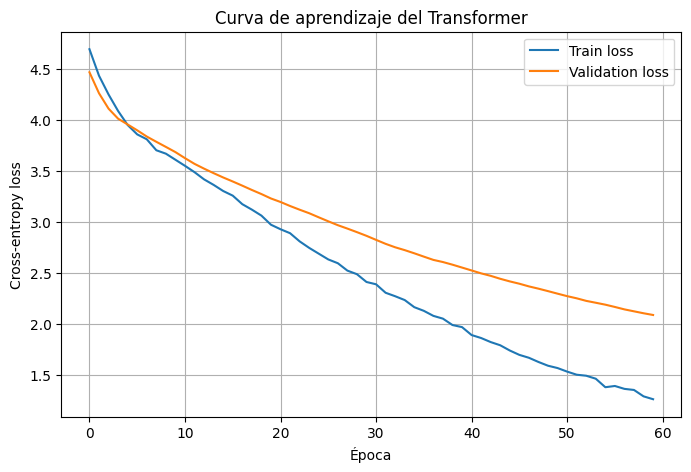

In [18]:
# Visualizar la curva de aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")
plt.title("Curva de aprendizaje del Transformer")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Inferencia con Greedy Coding

@torch.no_grad()
def greedy_translate(model, sentence, max_len=20):
    model.eval()

    src_ids = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

    src_mask = model.make_src_mask(src_tensor)

    encoder_output, _ = model.encode(src_tensor, src_mask)

    trg_ids = [trg_vocab.bos_idx]

    for _ in range(max_len):
        trg_tensor = torch.tensor(
            trg_ids,
            dtype=torch.long,
            device=DEVICE
        ).unsqueeze(0)

        trg_mask = model.make_trg_mask(trg_tensor)

        decoder_output, _, _ = model.decode(
            trg_tensor,
            encoder_output,
            trg_mask,
            src_mask
        )

        logits = model.output_layer(decoder_output[:, -1, :])

        next_token = torch.argmax(logits, dim=-1).item()

        trg_ids.append(next_token)

        if next_token == trg_vocab.eos_idx:
            break

    translation = trg_vocab.decode(trg_ids)

    return translation, trg_ids


# Pruebas de traducción
test_sentences = [
    "i am happy",
    "i like books",
    "where is the car",
    "she has a house",
    "they eat apples",
    "good night"
]

print("\nTraducciones de prueba:\n")

for sentence in test_sentences:
    translation, ids = greedy_translate(model, sentence)
    print(f"EN: {sentence}")
    print(f"FR: {translation}")
    print("-" * 50)


Traducciones de prueba:

EN: i am happy
FR: j aime les livres
--------------------------------------------------
EN: i like books
FR: j aime les livres
--------------------------------------------------
EN: where is the car
FR: la voiture est la voiture
--------------------------------------------------
EN: she has a house
FR: elle a une voiture
--------------------------------------------------
EN: they eat apples
FR: ils voient la voiture
--------------------------------------------------
EN: good night
FR: bonne nuit
--------------------------------------------------


In [20]:
# Obtener las atenciones para una oración
@torch.no_grad()
def get_attention_data(model, src_sentence, trg_sentence=None):
    """
    Devuelve:
    - tokens fuente
    - tokens objetivo usados como entrada del decoder
    - pesos de atención del encoder, decoder self-attention y cross-attention
    """

    model.eval()

    src_ids = src_vocab.encode(src_sentence)

    if trg_sentence is None:
        predicted_translation, predicted_ids = greedy_translate(model, src_sentence)
        trg_ids = predicted_ids
    else:
        trg_ids = trg_vocab.encode(trg_sentence)

    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(0)

    # Para analizar atención, usamos la entrada del decoder sin el último token.
    trg_input_ids = trg_ids[:-1]

    trg_tensor = torch.tensor(
        trg_input_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(0)

    logits, attentions = model(src_tensor, trg_tensor)

    src_tokens = [src_vocab.itos[i] for i in src_ids]
    trg_tokens = [trg_vocab.itos[i] for i in trg_input_ids]

    return src_tokens, trg_tokens, attentions


def plot_attention_matrix(attention, x_tokens, y_tokens, title):
    """
    attention:
    matriz [len(y_tokens), len(x_tokens)]
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(attention, aspect="auto", cmap="viridis")
    plt.colorbar(label="Peso de atención")

    plt.xticks(range(len(x_tokens)), x_tokens, rotation=45, ha="right")
    plt.yticks(range(len(y_tokens)), y_tokens)

    plt.xlabel("Tokens atendidos")
    plt.ylabel("Tokens que consultan")
    plt.title(title)

    plt.tight_layout()
    plt.show()


In [21]:
# Visualizar la atención en diferentes capas

src_sentence = "i like books"
trg_sentence = "j aime les livres"

src_tokens, trg_tokens, attentions = get_attention_data(
    model,
    src_sentence,
    trg_sentence=trg_sentence
)

print("Tokens fuente:", src_tokens)
print("Tokens objetivo:", trg_tokens)

Tokens fuente: ['<bos>', 'i', 'like', 'books', '<eos>']
Tokens objetivo: ['<bos>', 'j', 'aime', 'les', 'livres']


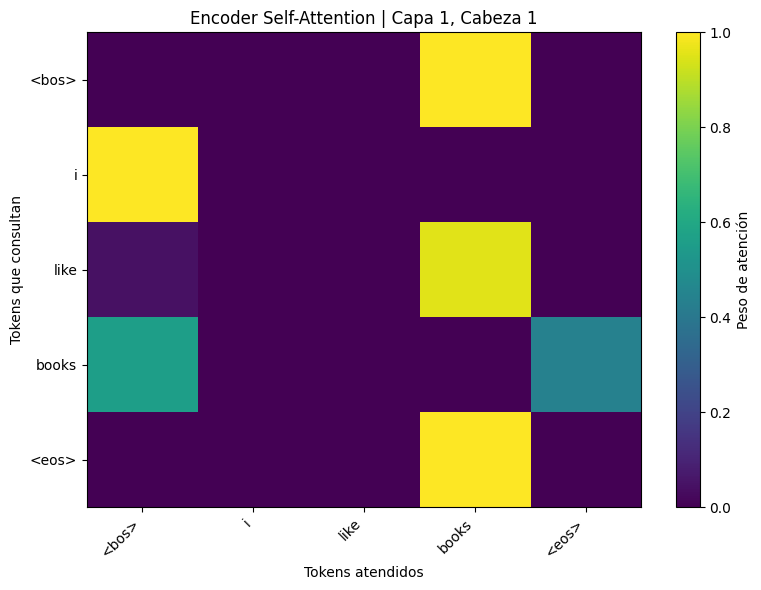

In [22]:
# Atención en el encoder
encoder_layer = 0
head = 0

encoder_attention = attentions["encoder"][encoder_layer][0, head].detach().cpu().numpy()

plot_attention_matrix(
    encoder_attention,
    x_tokens=src_tokens,
    y_tokens=src_tokens,
    title=f"Encoder Self-Attention | Capa {encoder_layer + 1}, Cabeza {head + 1}"
)

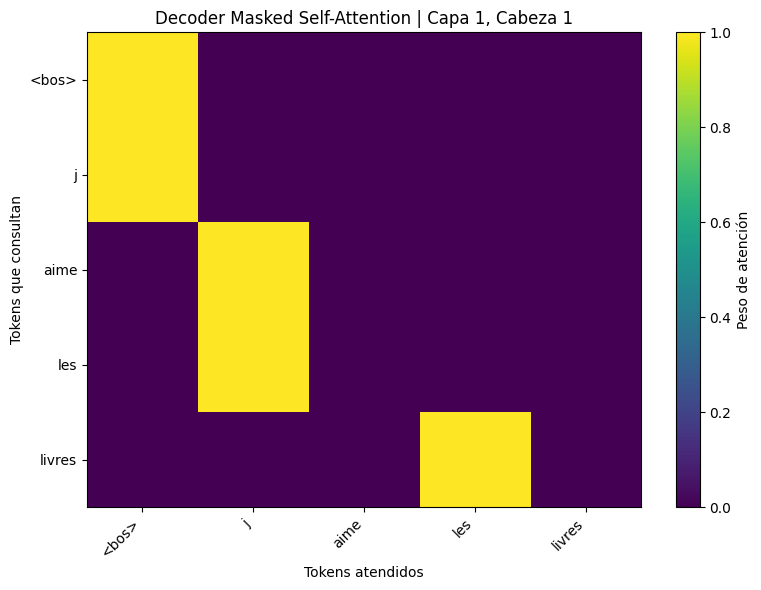

In [23]:
# Atención en el decoder
decoder_layer = 0
head = 0

decoder_self_attention = attentions["decoder_self"][decoder_layer][0, head].detach().cpu().numpy()

plot_attention_matrix(
    decoder_self_attention,
    x_tokens=trg_tokens,
    y_tokens=trg_tokens,
    title=f"Decoder Masked Self-Attention | Capa {decoder_layer + 1}, Cabeza {head + 1}"
)

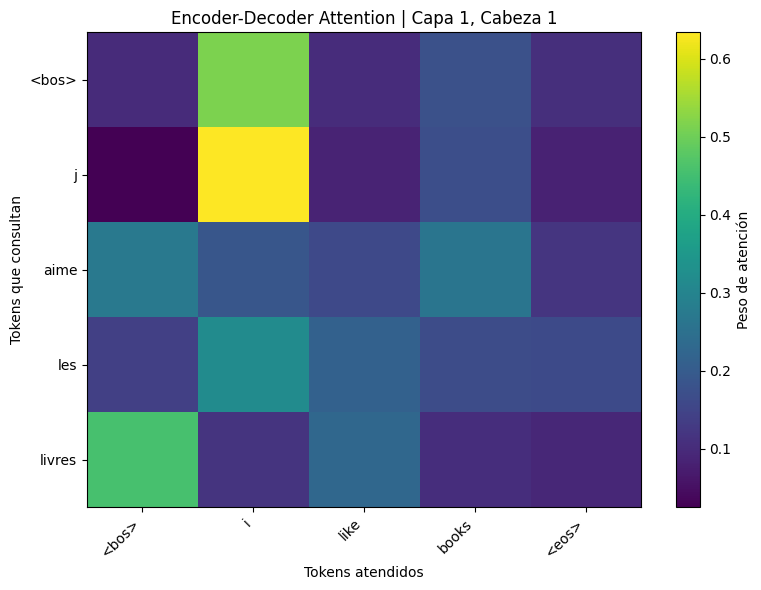

In [24]:
# Atención encoder-decoder
decoder_layer = 0
head = 0

cross_attention = attentions["decoder_cross"][decoder_layer][0, head].detach().cpu().numpy()

plot_attention_matrix(
    cross_attention,
    x_tokens=src_tokens,
    y_tokens=trg_tokens,
    title=f"Encoder-Decoder Attention | Capa {decoder_layer + 1}, Cabeza {head + 1}"
)

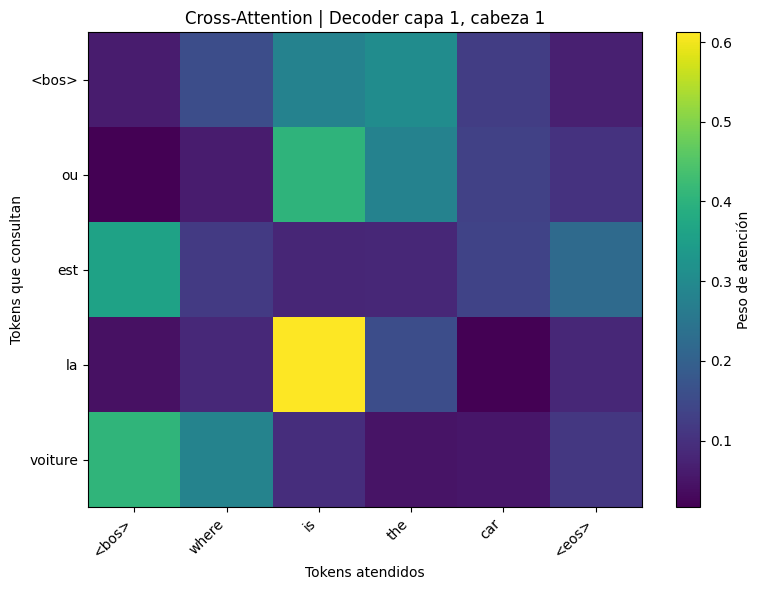

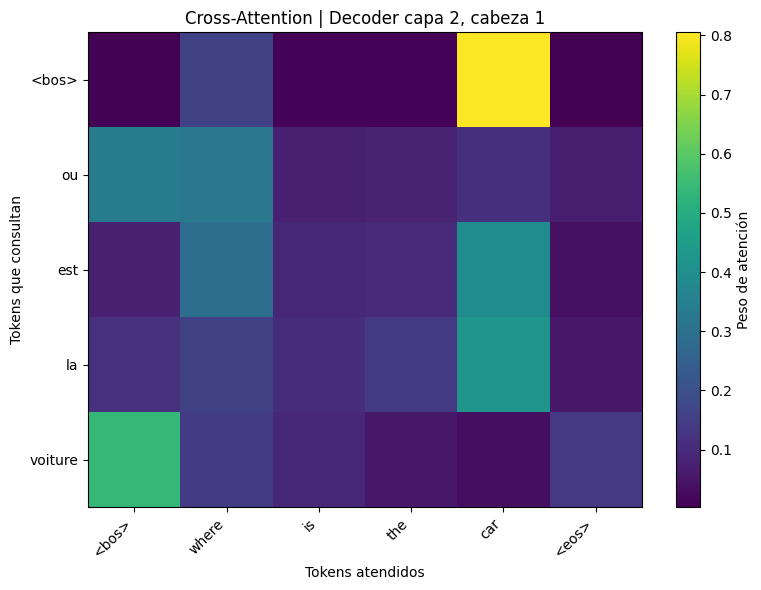

In [25]:
# Comparar la atención entre capas y cabezas
def compare_cross_attention_layers(model, src_sentence, trg_sentence, head=0):
    src_tokens, trg_tokens, attentions = get_attention_data(
        model,
        src_sentence,
        trg_sentence=trg_sentence
    )

    num_layers = len(attentions["decoder_cross"])

    for layer in range(num_layers):
        attention = attentions["decoder_cross"][layer][0, head].detach().cpu().numpy()

        plot_attention_matrix(
            attention,
            x_tokens=src_tokens,
            y_tokens=trg_tokens,
            title=f"Cross-Attention | Decoder capa {layer + 1}, cabeza {head + 1}"
        )


compare_cross_attention_layers(
    model,
    src_sentence="where is the car",
    trg_sentence="ou est la voiture",
    head=0
)